In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
def find_project_root(start: Path) -> Path:
    cur = start.resolve()
    for p in [cur] + list(cur.parents):
        if (p / "src").is_dir() and (p / "data").is_dir():
            return p
    raise RuntimeError(f"Could not find project root starting from {start}")

PROJECT_ROOT = find_project_root(Path.cwd())
analysis_dir = PROJECT_ROOT / "newAnalysis"   # <- rerun outputs
print("PROJECT_ROOT:", PROJECT_ROOT)
print("analysis_dir :", analysis_dir)
print("exists?      :", analysis_dir.exists())


PROJECT_ROOT: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project
analysis_dir : /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/newAnalysis
exists?      : True


In [3]:
# For ROC and t-SNE we need test_results + tsne for baseline/A4/A5 per model.
# These are the tags/filenames produced by the new analyzers.

MODEL_FILES = {
    "DomainCNN": {
        "baseline": ("domain_cnn_baseline_test_results.csv", "domain_cnn_baseline_tsne.csv"),
        "A4":       ("domain_cnn_A4_realistic_test_results.csv", "domain_cnn_A4_realistic_tsne.csv"),
        "A5":       ("domain_cnn_A5_noisy_test_results.csv", "domain_cnn_A5_noisy_tsne.csv"),
    },
    "CLIP-head": {
        "baseline": ("clip_domain_baseline_test_results.csv", "clip_domain_baseline_tsne.csv"),
        "A4":       ("clip_domain_A4_realistic_test_results.csv", "clip_domain_A4_realistic_tsne.csv"),
        "A5":       ("clip_domain_A5_noisy_test_results.csv", "clip_domain_A5_noisy_tsne.csv"),
    },
    "ConvNeXt-head": {
        "baseline": ("convnext_baseline_test_results.csv", "convnext_baseline_tsne.csv"),
        "A4":       ("convnext_A4_realistic_test_results.csv", "convnext_A4_realistic_tsne.csv"),
        "A5":       ("convnext_A5_noisy_test_results.csv", "convnext_A5_noisy_tsne.csv"),
    },
    "ViT-head": {
        "baseline": ("vit_baseline_test_results.csv", "vit_baseline_tsne.csv"),
        "A4":       ("vit_A4_realistic_test_results.csv", "vit_A4_realistic_tsne.csv"),
        "A5":       ("vit_A5_noisy_test_results.csv", "vit_A5_noisy_tsne.csv"),
    },
}

def path_in_analysis(fname: str) -> Path:
    return analysis_dir / fname

# quick sanity: show missing files
missing = []
for model, variants in MODEL_FILES.items():
    for var, (res_fn, tsne_fn) in variants.items():
        if not path_in_analysis(res_fn).exists():
            missing.append((model, var, res_fn))
        if not path_in_analysis(tsne_fn).exists():
            missing.append((model, var, tsne_fn))
if missing:
    print("Missing files:")
    for m in missing[:50]:
        print(" ", m)
else:
    print("All expected files are present ✅")


Missing files:
  ('DomainCNN', 'baseline', 'domain_cnn_baseline_tsne.csv')
  ('DomainCNN', 'A5', 'domain_cnn_A5_noisy_tsne.csv')
  ('CLIP-head', 'baseline', 'clip_domain_baseline_tsne.csv')


In [4]:
def load_test_results(fname: str) -> pd.DataFrame:
    p = path_in_analysis(fname)
    if not p.exists():
        raise FileNotFoundError(p)
    return pd.read_csv(p)

def load_tsne(fname: str) -> pd.DataFrame:
    p = path_in_analysis(fname)
    if not p.exists():
        raise FileNotFoundError(p)
    return pd.read_csv(p)


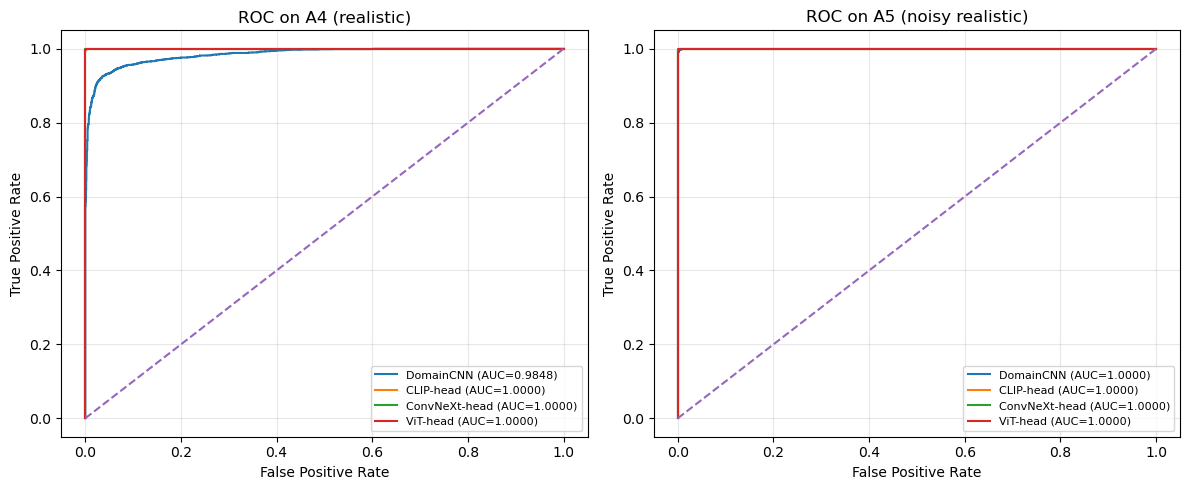

In [5]:
from sklearn.metrics import roc_curve, auc

def plot_roc_panel(ax, variant_key: str, title: str):
    for model, variants in MODEL_FILES.items():
        res_fn, _ = variants[variant_key]
        p = path_in_analysis(res_fn)
        if not p.exists():
            print("[missing]", p.name, "-> skipping", model, variant_key)
            continue
        df = pd.read_csv(p)

        y_true = df["true_label"].to_numpy()
        y_score = df["prob_fake"].to_numpy()

        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{model} (AUC={roc_auc:.4f})")

    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_roc_panel(axes[0], "A4", "ROC on A4 (realistic)")
plot_roc_panel(axes[1], "A5", "ROC on A5 (noisy realistic)")
plt.tight_layout()
plt.show()


In [6]:
def plot_tsne_grid_for_model(model_name: str, point_size=5, alpha=0.4):
    variants_order = ["baseline", "A4", "A5"]
    files = MODEL_FILES[model_name]

    available = []
    for v in variants_order:
        _, tsne_fn = files[v]
        if path_in_analysis(tsne_fn).exists():
            available.append(v)
        else:
            print(f"[missing tsne] {model_name} {v} -> {tsne_fn}")

    if not available:
        print("No t-SNE files found for", model_name)
        return

    cols = 3
    rows = int(np.ceil(len(available) / cols))
    plt.figure(figsize=(5 * cols, 4 * rows))

    for i, v in enumerate(available, start=1):
        _, tsne_fn = files[v]
        df = pd.read_csv(path_in_analysis(tsne_fn))

        iam_mask = (df["true_label"].to_numpy() == 0)
        emu_mask = (df["true_label"].to_numpy() == 1)
        mis_mask = (df["true_label"] != df["pred_label"]).to_numpy()

        ax = plt.subplot(rows, cols, i)

        ax.scatter(df.loc[iam_mask, "tsne_x"], df.loc[iam_mask, "tsne_y"],
                   s=point_size, alpha=alpha, label="IAM")
        ax.scatter(df.loc[emu_mask, "tsne_x"], df.loc[emu_mask, "tsne_y"],
                   s=point_size, alpha=alpha, label="Emuru")

        if mis_mask.any():
            ax.scatter(df.loc[mis_mask, "tsne_x"], df.loc[mis_mask, "tsne_y"],
                       s=30, edgecolors="k", facecolors="none", linewidths=1.0,
                       label="Miscls.")

        ax.set_title(f"{model_name} – {v}")
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 1:
            ax.legend(fontsize=8)

    plt.suptitle(f"t-SNE (baseline / A4 / A5) — {model_name}", y=1.02)
    plt.tight_layout()
    plt.show()


[missing tsne] DomainCNN baseline -> domain_cnn_baseline_tsne.csv
[missing tsne] DomainCNN A5 -> domain_cnn_A5_noisy_tsne.csv


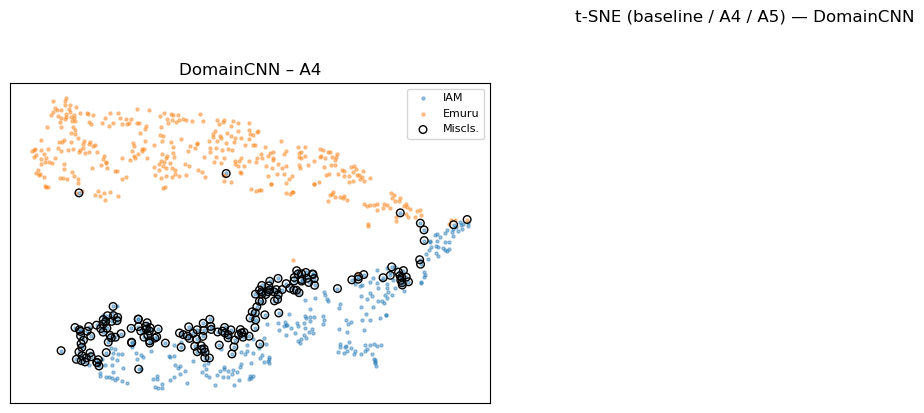

[missing tsne] CLIP-head baseline -> clip_domain_baseline_tsne.csv


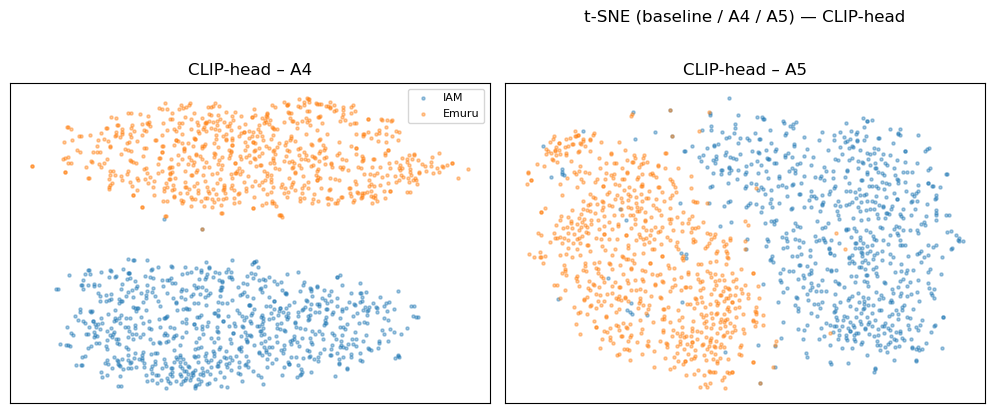

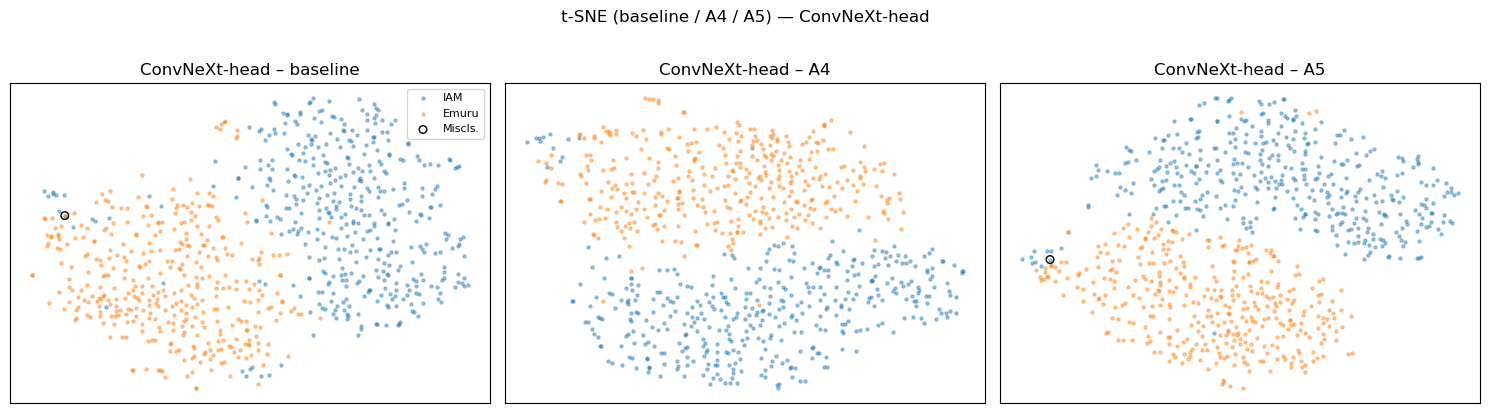

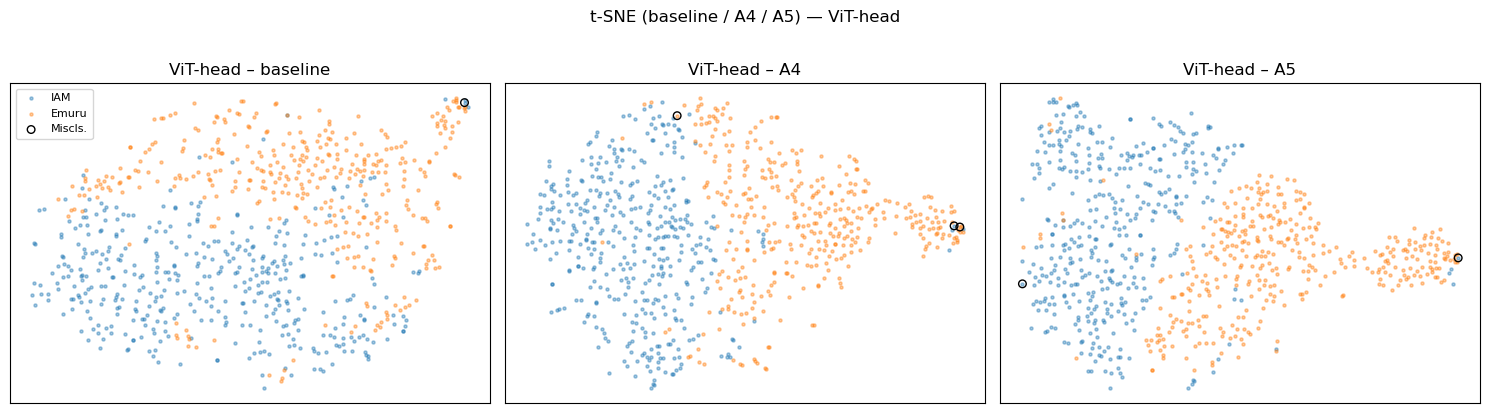

In [7]:
for model_name in MODEL_FILES.keys():
    plot_tsne_grid_for_model(model_name)
